In [2]:
# importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Data Loading

In [40]:

from google.colab import files

uploaded = files.upload()

Saving store_sales.csv to store_sales.csv


In [5]:
# path ='/content/drive/MyDrive/train (1).csv'



Data Details

In [43]:
train = pd.read_csv('store_sales.csv')


In [44]:
train.head()

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [45]:
train.shape

(7300, 5)

In [46]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   object 
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 285.3+ KB


Convert date

In [47]:
train['date'] = pd.to_datetime(train['date'])

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7300 non-null   datetime64[ns]
 1   store    7300 non-null   int64         
 2   sales    7300 non-null   float64       
 3   promo    7300 non-null   int64         
 4   holiday  7300 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 285.3 KB


Checking for date range

In [48]:
print("Start date:", train['date'].min())
print("End date:", train['date'].max())

Start date: 2022-01-01 00:00:00
End date: 2023-12-31 00:00:00


##Data Cleaning

Check duplicate rows

In [51]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


Checking Missing Values

In [52]:
print(train.isnull().sum())

date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64


Checking DataTypes

In [53]:
print(train.dtypes)

date       datetime64[ns]
store               int64
sales             float64
promo               int64
holiday             int64
dtype: object


Check for invalid sales values

In [54]:
print("Negative sales:", (train['sales'] < 0).sum())

Negative sales: 0


Checking for Unique IDs

In [58]:
print("Unique IDs:", train['date'].nunique())
print("Total rows:", len(train))

Unique IDs: 730
Total rows: 7300


Checking Actual Variables

In [59]:
print("\nPromotion values:")
print(train['promo'].value_counts())

print("\nHoliday values:")
print(train['holiday'].value_counts())


Promotion values:
promo
0    5824
1    1476
Name: count, dtype: int64

Holiday values:
holiday
0    6540
1     760
Name: count, dtype: int64


Basic data validation

In [60]:
print("Negative sales:", (train['sales'] < 0).sum())
print("Negative promotion values:", (train['promo'] < 0).sum())
print("Total rows:", len(train))

Negative sales: 0
Negative promotion values: 0
Total rows: 7300


Copy of clean data

In [21]:
clean_train = train.copy()

Saving clean dataset in drive for record

In [22]:
import os

save_path = '/content/drive/MyDrive/'
os.makedirs(save_path, exist_ok=True)

clean_train.to_csv(
    f'{save_path}/clean_train.csv',
    index=False
)

print("Clean dataset saved successfully!")
print(f"Location: {save_path}/clean_train.csv")

Clean dataset saved successfully!
Location: /content/drive/MyDrive//clean_train.csv


Create the date features

In [23]:
clean_train = train.copy()

clean_train['year'] = clean_train['date'].dt.year
clean_train['month'] = clean_train['date'].dt.month
clean_train['day'] = clean_train['date'].dt.day
clean_train['day_of_week'] = clean_train['date'].dt.dayofweek
clean_train['is_weekend'] = clean_train['day_of_week'].isin([5, 6]).astype(int)

clean_train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,0


Check

In [24]:
clean_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 11 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   year         int32         
 7   month        int32         
 8   day          int32         
 9   day_of_week  int32         
 10  is_weekend   int64         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(4), object(1)
memory usage: 206.1+ MB


Check for Negative Sale values

In [25]:
print("Negative sales:", (clean_train['sales'] < 0).sum())
print("Negative promotions:", (clean_train['onpromotion'] < 0).sum())

Negative sales: 0
Negative promotions: 0


##EDA(Exploratory Data Analysis)

Total sales by year

In [26]:
yearly_sales = clean_train.groupby('year')['sales'].sum()

print(yearly_sales)

year
2013    1.404190e+08
2014    2.094742e+08
2015    2.408801e+08
2016    2.886545e+08
2017    1.942171e+08
Name: sales, dtype: float64


Visualization

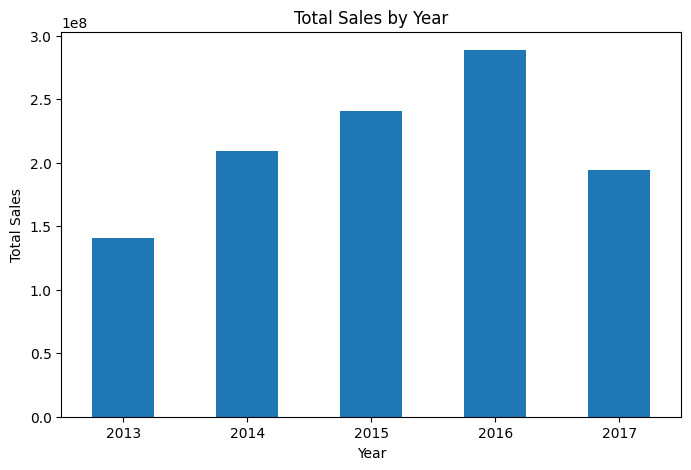

In [27]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind='bar')

plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

###How have sales changed over the years?

Sales increased steadily from 140.4M (2013) to 288.7M (2016). 2017 has 194.2M, but it only includes data until August.

Total sales by product family

In [28]:
family_sales = (
    clean_train.groupby('family')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(family_sales)

family
GROCERY I                     3.434627e+08
BEVERAGES                     2.169545e+08
PRODUCE                       1.227047e+08
CLEANING                      9.752129e+07
DAIRY                         6.448771e+07
BREAD/BAKERY                  4.213395e+07
POULTRY                       3.187600e+07
MEATS                         3.108647e+07
PERSONAL CARE                 2.459205e+07
DELI                          2.411032e+07
HOME CARE                     1.602274e+07
EGGS                          1.558830e+07
FROZEN FOODS                  1.407389e+07
PREPARED FOODS                8.799895e+06
LIQUOR,WINE,BEER              7.746640e+06
SEAFOOD                       2.015432e+06
GROCERY II                    1.962767e+06
HOME AND KITCHEN I            1.861491e+06
HOME AND KITCHEN II           1.520670e+06
CELEBRATION                   7.611770e+05
LINGERIE                      6.531140e+05
LADIESWEAR                    6.511590e+05
PLAYERS AND ELECTRONICS       5.626080e+05
AUTO

Visualize

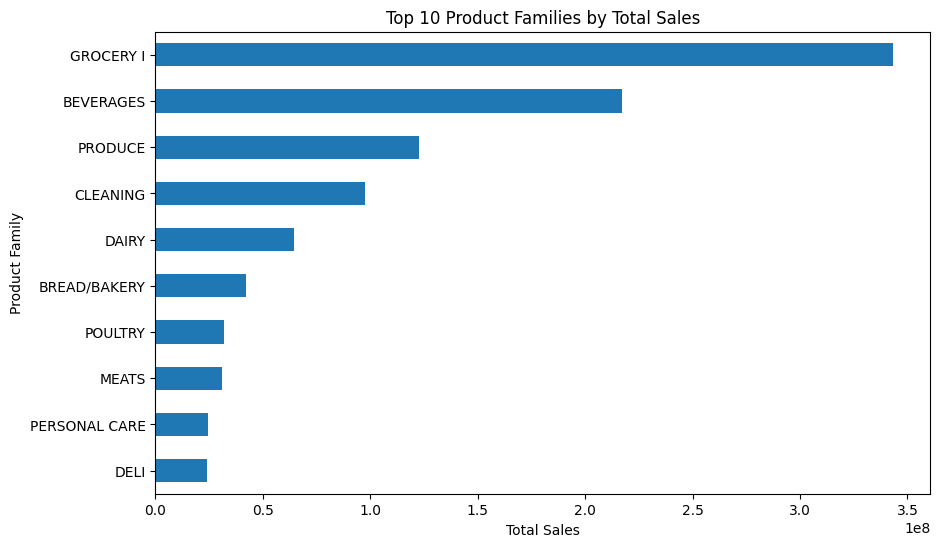

In [29]:
plt.figure(figsize=(10, 6))

family_sales.head(10).plot(kind='barh')

plt.title('Top 10 Product Families by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Family')
plt.gca().invert_yaxis()

plt.show()


###Which product categories generate the most sales?

GROCERY I has the highest sales (343.5M), followed by BEVERAGES (217.0M) and PRODUCE (122.7M).

MOnthly Sales Trend

In [30]:
monthly_sales = (
    train.groupby(train['date'].dt.to_period('M'))['sales']
    .sum()
)

monthly_sales.head()

,sales
date,
2013-01,1.032762e+07
2013-02,9.658960e+06
2013-03,1.142850e+07
2013-04,1.099346e+07
2013-05,1.159770e+07


Visualize

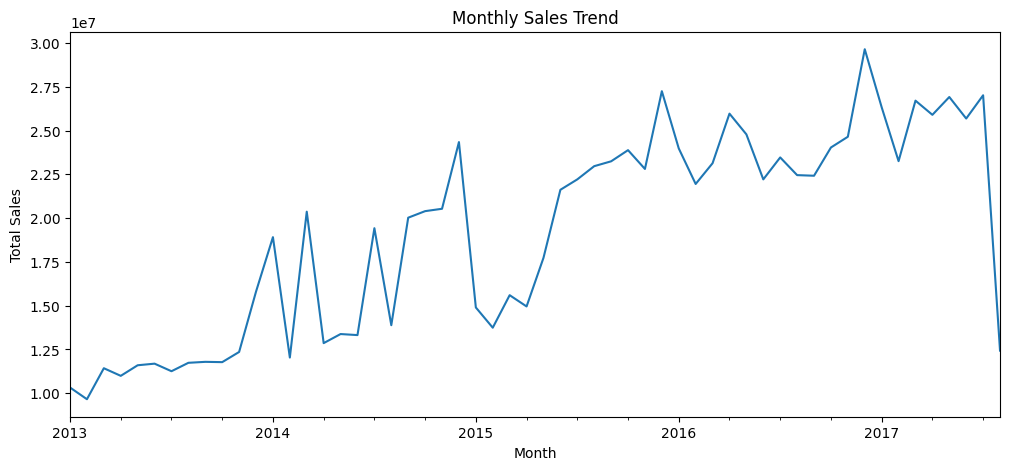

In [31]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

###Q3. How do sales change month by month?
 We will write this answer based on the monthly graph/output you generated.

Which store has the highest Sales

In [32]:
store_sales = (
    train.groupby('store_nbr')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(store_sales.head(10))

store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
46    4.189606e+07
48    3.593313e+07
51    3.291149e+07
8     3.049429e+07
50    2.865302e+07
Name: sales, dtype: float64


Visualize

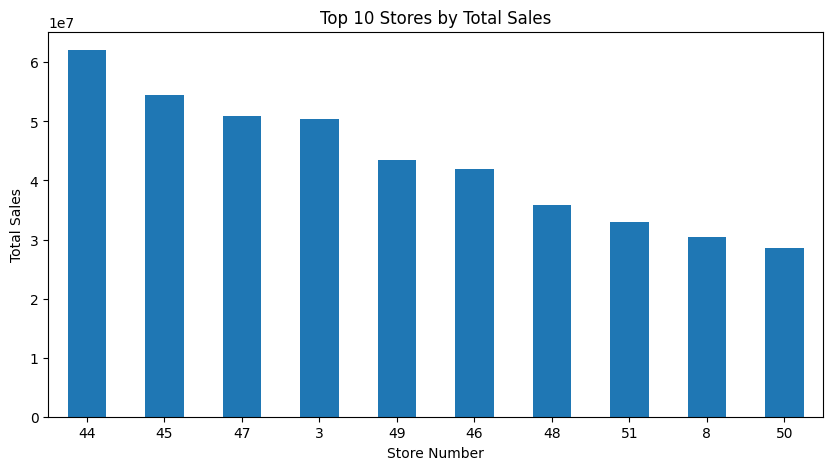

In [33]:
plt.figure(figsize=(10, 5))

store_sales.head(10).plot(kind='bar')

plt.title('Top 10 Stores by Total Sales')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

###Q4. Which stores have the highest sales?

 We will write this answer based on your top-store output.

Does Promotion affect sales

In [34]:
promotion_sales = (
    train.groupby(train['onpromotion'] > 0)['sales']
    .mean()
)

print(promotion_sales)

onpromotion
False     158.246681
True     1137.693730
Name: sales, dtype: float64


In [35]:
print("Average sales without promotion:",
      promotion_sales[False])

print("Average sales with promotion:",
      promotion_sales[True])

Average sales without promotion: 158.24668139364272
Average sales with promotion: 1137.6937303133943


###Q5. Does promotion affect sales?

 We will write this after seeing your promotion results.

Average sales by day of the week

In [36]:
day_sales = (
    train.groupby(train['date'].dt.day_name())['sales']
    .mean()
)

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_sales = day_sales.reindex(day_order)

print(day_sales)

date
Monday       346.544732
Tuesday      319.823843
Wednesday    332.909401
Thursday     283.540517
Friday       325.238138
Saturday     433.336472
Sunday       463.085366
Name: sales, dtype: float64


Visualization

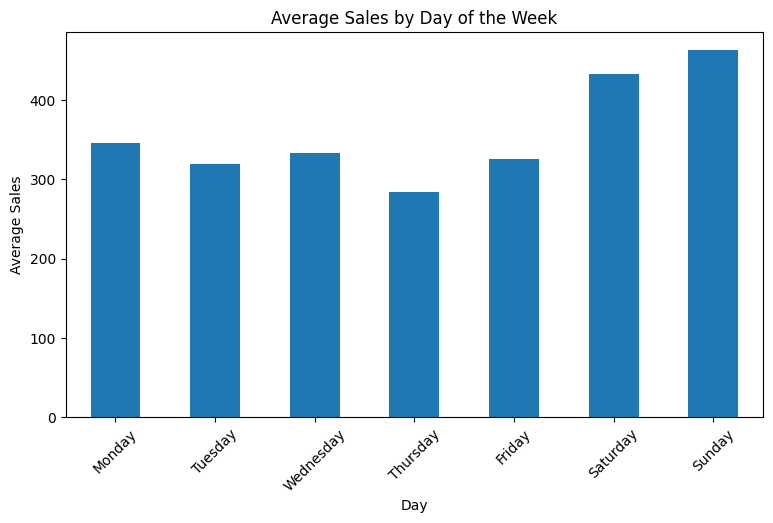

In [37]:
plt.figure(figsize=(9, 5))

day_sales.plot(kind='bar')

plt.title('Average Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)

plt.show()

Q6: What is the average sales by day of the week?

Product families with highest average sales

In [38]:
family_avg_sales = (
    train.groupby('family')['sales']
    .mean()
    .sort_values(ascending=False)
)

print(family_avg_sales)

family
GROCERY I                     3776.972100
BEVERAGES                     2385.793151
PRODUCE                       1349.352123
CLEANING                      1072.416744
DAIRY                          709.154889
BREAD/BAKERY                   463.336254
POULTRY                        350.532292
MEATS                          341.849965
PERSONAL CARE                  270.432513
DELI                           265.135067
HOME CARE                      176.198029
EGGS                           171.420516
FROZEN FOODS                   154.766954
PREPARED FOODS                  96.770202
LIQUOR,WINE,BEER                85.187824
SEAFOOD                         22.163190
GROCERY II                      21.584048
HOME AND KITCHEN I              20.470342
HOME AND KITCHEN II             16.722420
CELEBRATION                      8.370469
LINGERIE                         7.182128
LADIESWEAR                       7.160629
PLAYERS AND ELECTRONICS          6.186857
AUTOMOTIVE                 

Visualize

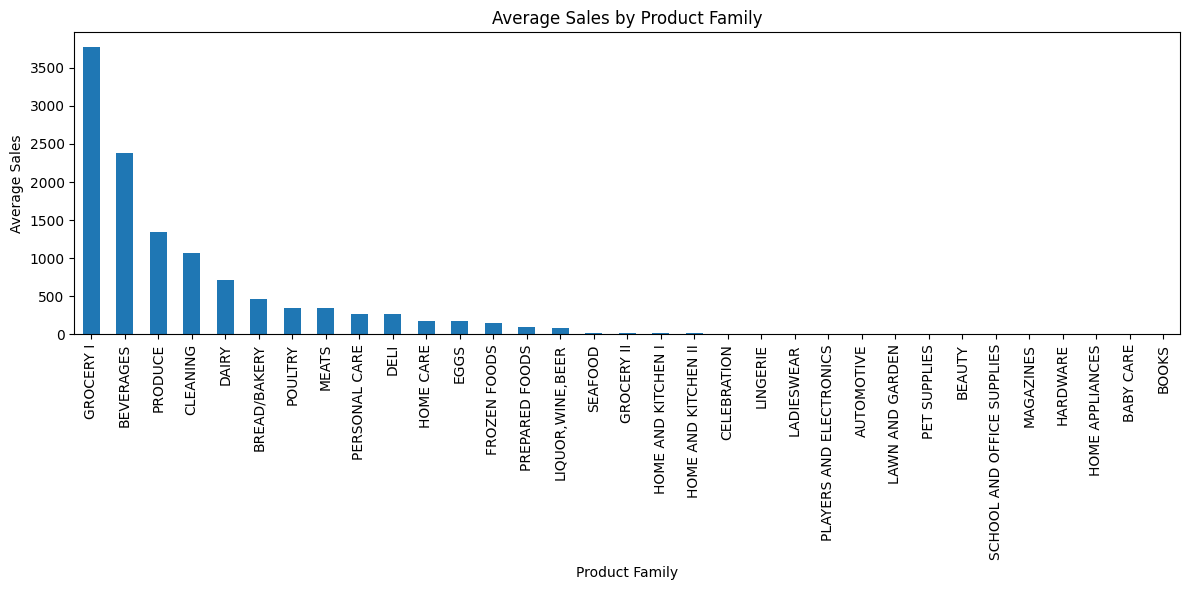

In [39]:
plt.figure(figsize=(12, 6))

family_avg_sales.plot(kind='bar')

plt.title('Average Sales by Product Family')
plt.xlabel('Product Family')
plt.ylabel('Average Sales')

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

###Q7. Which product families have the highest average sales?